In [1]:
!pip -q install mediapipe opencv-python tqdm tensorflow scikit-learn

In [2]:
# from google.colab import drive
# drive.flush_and_unmount()

# !rm -rf /content/drive
# !mkdir -p /content/drive


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')


In [4]:
# import os
# print("MyDrive:", os.listdir("/content/drive/MyDrive")[:50])


In [5]:
# print(os.listdir("/content/drive/MyDrive/dataset"))


In [1]:
import os

RAW_DIR = r"C:\Users\Admin\OneDrive\Desktop\sem2\Innovation\archive"

# ✅ Debug - check if path exists
print("Archive exists:", os.path.exists(RAW_DIR))
print("Contents:", os.listdir(RAW_DIR) if os.path.exists(RAW_DIR) else "NOT FOUND")

# Check training and testing
train_path = os.path.join(RAW_DIR, "training_set")
test_path = os.path.join(RAW_DIR, "testing_set")
print("training_set exists:", os.path.exists(train_path))
print("testing_set exists:", os.path.exists(test_path))

Archive exists: True
Contents: ['FaceShape Dataset']
training_set exists: False
testing_set exists: False


In [2]:
import os

RAW_DIR = r"C:\Users\Admin\OneDrive\Desktop\sem2\Innovation\archive\FaceShape Dataset"

print("Contents:", os.listdir(RAW_DIR))
print("training_set exists:", os.path.exists(os.path.join(RAW_DIR, "training_set")))
print("testing_set exists:", os.path.exists(os.path.join(RAW_DIR, "testing_set")))

Contents: ['desktop.ini', 'testing_set', 'training_set']
training_set exists: True
testing_set exists: True


In [3]:
import os, cv2, math
from tqdm import tqdm
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
RAW_DIR  = r"C:\Users\Admin\OneDrive\Desktop\sem2\Innovation\archive\FaceShape Dataset"
PROC_DIR = r"C:\Users\Admin\OneDrive\Desktop\sem2\Innovation\archive_processed_224"

IMG_SIZE = 224
TOP_MARGIN = 0.35
BOTTOM_MARGIN = 0.60
SIDE_MARGIN = 0.28
EXTS = (".jpg",".jpeg",".png",".webp")

os.makedirs(PROC_DIR, exist_ok=True)

# ✅ Download the new face landmarker model
MODEL_PATH = "face_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading face landmarker model...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        MODEL_PATH
    )
    print("Model downloaded ✅")

# ✅ New API setup
base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

def clamp(v, lo, hi): return max(lo, min(hi, v))

def rotate(img, angle, center):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE), M

def apply(M, x, y):
    return (M[0,0]*x + M[0,1]*y + M[0,2],
            M[1,0]*x + M[1,1]*y + M[1,2])

def preprocess_one(detector, img):
    h, w = img.shape[:2]

    # ✅ New API: use mp.Image instead of cv2 cvtColor pass
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    res = detector.detect(mp_image)

    if not res.face_landmarks:
        print("Nothing detected")
        return None

    # ✅ New API: landmarks are already normalized (x, y between 0-1)
    lms = res.face_landmarks[0]
    pts = [(p.x * w, p.y * h) for p in lms]

    # align by outer eye corners (same landmark indices)
    lx, ly = pts[33]
    rx, ry = pts[263]
    angle = math.degrees(math.atan2(ry - ly, rx - lx))

    rot, M = rotate(img, -angle, (w/2, h/2))
    rpts = [apply(M, x, y) for x, y in pts]
    xs, ys = zip(*rpts)
    x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
    fw, fh = x2 - x1, y2 - y1
    if fw <= 2 or fh <= 2:
        return None

    nx1 = int(clamp(x1 - SIDE_MARGIN*fw, 0, w-1))
    nx2 = int(clamp(x2 + SIDE_MARGIN*fw, 0, w-1))
    ny1 = int(clamp(y1 - TOP_MARGIN*fh, 0, h-1))
    ny2 = int(clamp(y2 + BOTTOM_MARGIN*fh, 0, h-1))

    if nx2 <= nx1 or ny2 <= ny1:
        return None

    crop = rot[ny1:ny2, nx1:nx2]
    if crop.size == 0:
        return None

    return cv2.resize(crop, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

def run_split(split):
    src = os.path.join(RAW_DIR, split)
    dst = os.path.join(PROC_DIR, split)
    os.makedirs(dst, exist_ok=True)

    classes = [d for d in os.listdir(src) if os.path.isdir(os.path.join(src, d))]
    for c in classes:
        os.makedirs(os.path.join(dst, c), exist_ok=True)

    saved = failed = skipped = 0

    # ✅ New API: create detector once and reuse
    with vision.FaceLandmarker.create_from_options(options) as detector:
        for c in classes:
            in_cls = os.path.join(src, c)
            out_cls = os.path.join(dst, c)

            files = [f for f in os.listdir(in_cls) if f.lower().endswith(EXTS)]
            for f in tqdm(files, desc=f"{split}/{c}"):
                out_path = os.path.join(out_cls, os.path.splitext(f)[0] + ".jpg")

                if os.path.exists(out_path):
                    skipped += 1
                    continue

                img = cv2.imread(os.path.join(in_cls, f))
                if img is None:
                    failed += 1
                    continue

                out = preprocess_one(detector, img)
                if out is None:
                    failed += 1
                    continue

                if cv2.imwrite(out_path, out):
                    saved += 1
                else:
                    failed += 1

    print(f"[{split}] saved={saved} skipped={skipped} failed={failed}")

run_split("training_set")
run_split("testing_set")
print("✅ Done. Saved to:", PROC_DIR)

training_set/Square: 100%|██████████| 800/800 [00:00<00:00, 11503.34it/s]


[training_set] saved=0 skipped=3999 failed=1


testing_set/Square: 100%|██████████| 200/200 [00:00<00:00, 15438.97it/s]

[testing_set] saved=0 skipped=1000 failed=0
✅ Done. Saved to: C:\Users\Admin\OneDrive\Desktop\sem2\Innovation\archive_processed_224


In [4]:
import tensorflow as tf
import os

PROC_DIR = "C:\\Users\\Admin\\OneDrive\\Desktop\\sem2\\Innovation\\archive_processed_224"
IMG_SIZE = (224, 224)
BATCH = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROC_DIR, "training_set"),
    image_size=IMG_SIZE,
    batch_size=BATCH,
    seed=SEED,
    label_mode="categorical",
    shuffle=True,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROC_DIR, "testing_set"),
    image_size=IMG_SIZE,
    batch_size=BATCH,
    seed=SEED,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classees:", num_classes)


# ✅ Count class distribution
class_counts = {}
for c in class_names:
    path = os.path.join(PROC_DIR, "training_set", c)
    class_counts[c] = len(os.listdir(path))
    print(f"  {c}: {class_counts[c]} images")


# ✅ Compute class weights to handle imbalance
total = sum(class_counts.values())
class_weights = {
    i: total / (num_classes * class_counts[class_names[i]])
    for i in range(num_classes)
}
print("\nClass weights:", class_weights)



AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 3999 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.
Classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
Number of classees: 5
  Heart: 800 images
  Oblong: 799 images
  Oval: 800 images
  Round: 800 images
  Square: 800 images

Class weights: {0: 0.99975, 1: 1.0010012515644555, 2: 0.99975, 3: 0.99975, 4: 0.99975}


In [5]:
# from tensorflow.keras import layers
# from tensorflow.keras.applications import EfficientNetB0
# import tensorflow as tf

# aug = tf.keras.Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.08),
#     layers.RandomZoom(0.10),
#     layers.RandomContrast(0.10),
# ], name="aug")

# base = EfficientNetB0(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
# base.trainable = False  # stage 1

# inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
# x = aug(inputs)
# x = tf.keras.applications.efficientnet.preprocess_input(x)
# x = base(x, training=False)
# x = layers.GlobalAveragePooling2D()(x)

# # ✅ Added extra dense layer for better learning
# x = layers.Dense(256, activation="relu")(x)
# x = layers.BatchNormalization()(x)
# x = layers.Dropout(0.40)(x)
# x = layers.Dense(128, activation="relu")(x)
# x = layers.Dropout(0.30)(x)



# outputs = layers.Dense(num_classes, activation="softmax")(x)

# model = tf.keras.Model(inputs, outputs)

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-3),
#     loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
#     metrics=["accuracy"],
# )

# model.summary()

# best_path = "face_shape_best.keras"

# callbacks = [
#     tf.keras.callbacks.ModelCheckpoint(best_path, save_best_only=True, monitor="val_accuracy", mode="max",verbose=1),
#     tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor="val_accuracy",verbose=1),
#     tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3, monitor="val_loss",min_lr=1e-7,verbose=1),
# ]

# print("=== Stage 1: Train head (base frozen) ===")
# hist1 = model.fit(train_ds, validation_data=test_ds, epochs=15, callbacks=callbacks,class_weight=class_weights)

# print("Saved best model to:", best_path)

from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
import tensorflow as tf

# ── Stage 1: frozen backbone ──────────────────────────────────────────────────
base = EfficientNetB0(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base.trainable = True

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base(x, training=True )
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

best_path = "face_shape_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(best_path, save_best_only=True, monitor="val_accuracy", mode="max", verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor="val_accuracy", verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3, monitor="val_loss", min_lr=1e-7, verbose=1),
]

print("=== Stage 1: Train head (base frozen) ===")
hist1 = model.fit(train_ds, validation_data=test_ds, epochs=15, callbacks=callbacks, class_weight=class_weights)
print("Stage 1 complete. Best model saved to:", best_path)

# ── Stage 2: full fine-tune ───────────────────────────────────────────────────
model.load_weights(best_path)  # start from best stage-1 checkpoint

base.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  # 10× lower LR to protect pretrained weights
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

print("=== Stage 2: Fine-tune full network ===")
hist2 = model.fit(train_ds, validation_data=test_ds, epochs=30, callbacks=callbacks, class_weight=class_weights)
print("Stage 2 complete. Best model saved to:", best_path)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 4,013,953 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

=== Stage 1: Train head (base frozen) ===
Epoch 1/15
  2/125 ━━━━━━━━━━━━━━━━━━━━ 7:19 4s/step - accuracy: 0.2578 - loss: 1.6127  

KeyboardInterrupt: 

In [9]:
import tensorflow as tf

# Unfreeze more of the backbone
base.trainable = True

# Freeze only the very early layers (keep low-level edges stable)
for layer in base.layers[:100]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/face_shape_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=6,
        restore_best_weights=True,
        monitor="val_accuracy",
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=2,
        factor=0.5,
        monitor="val_loss",
        min_lr=5e-7,
    ),
]

print("=== Stage 2: stronger fine-tune ===")
hist2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=25,
    callbacks=callbacks,
)

model.save("/content/drive/MyDrive/face_shape_final.keras")
print("✅ Saved final model to Drive")


=== Stage 2: stronger fine-tune ===
Epoch 1/25


125/125 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.4671 - loss: 1.3839 - val_accuracy: 0.4190 - val_loss: 1.4216 - learning_rate: 3.0000e-06
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.4691 - loss: 1.3663 - val_accuracy: 0.4370 - val_loss: 1.4092 - learning_rate: 3.0000e-06
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.4946 - loss: 1.3393 - val_accuracy: 0.4520 - val_loss: 1.3958 - learning_rate: 3.0000e-06
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.5154 - loss: 1.3183 - val_accuracy: 0.4500 - val_loss: 1.3811 - learning_rate: 3.0000e-06
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.5209 - loss: 1.3059 - val_accuracy: 0.4610 - val_loss: 1.3668 - learning_rate: 3.0000e-06
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.5294 - loss: 1.2823 - val_accuracy: 0.4760 - val_loss: 1.3519 - learning_rate: 3.0000e-06
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.54

In [12]:
import tensorflow as tf
import os

PROC_DIR = "C:\\Users\\Admin\\OneDrive\\Desktop\\sem2\\Innovation\\archive_processed_224"

# Re-load ONLY to get class names (fast, no training)
tmp_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROC_DIR, "training_set"),
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical",
    shuffle=False,
)

class_names = tmp_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("num_classes:", num_classes)
del tmp_ds


Found 3999 files belonging to 5 classes.
Classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
num_classes: 5


In [13]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (224, 224)

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.10),
], name="aug")

base = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights="imagenet",
)
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = aug(inputs)
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_v2 = tf.keras.Model(inputs, outputs)

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/face_shape_v2_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
    ),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss"),
]

print("=== V2 Stage 1 (frozen backbone) ===")
hist1_v2 = model_v2.fit(train_ds, validation_data=test_ds, epochs=15, callbacks=callbacks)


=== V2 Stage 1 (frozen backbone) ===
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 51s 349ms/step - accuracy: 0.2601 - loss: 1.5995 - val_accuracy: 0.3440 - val_loss: 1.5156 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 308ms/step - accuracy: 0.3568 - loss: 1.5009 - val_accuracy: 0.3720 - val_loss: 1.4744 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 309ms/step - accuracy: 0.3778 - loss: 1.4631 - val_accuracy: 0.3560 - val_loss: 1.4606 - learning_rate: 0.0010
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 315ms/step - accuracy: 0.3963 - loss: 1.4377 - val_accuracy: 0.3970 - val_loss: 1.4377 - learning_rate: 0.0010
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 309ms/step - accuracy: 0.4284 - loss: 1.4024 - val_accuracy: 0.4020 - val_loss: 1.4315 - learning_rate: 0.0010
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 312ms/step - accuracy: 0.4249 - loss: 1.4022 - val_accuracy: 0.4040 - val_loss: 1.4217 - learning_rate: 0.0010
Epoch 7/15
125/125 ━━━━━━━━━━━━━━

In [23]:
import tensorflow as tf

# Unfreeze backbone for fine-tuning
base.trainable = True

# Freeze early layers only (keep low-level edges stable)
for layer in base.layers[:120]:
    layer.trainable = False

# Re-compile with a very small LR
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

print("=== V2 Stage 2 (fine-tune) ===")
hist2_v2 = model_v2.fit(
    train_ds,
    validation_data=test_ds,
    epochs=25,
    callbacks=callbacks,
)

model_v2.save("/content/drive/MyDrive/face_shape_v2_final.keras")
print("✅ Saved: /content/drive/MyDrive/face_shape_v2_final.keras")


=== V2 Stage 2 (fine-tune) ===
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 100s 648ms/step - accuracy: 0.3153 - loss: 1.5631 - val_accuracy: 0.3390 - val_loss: 1.5322 - learning_rate: 3.0000e-06
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 78s 626ms/step - accuracy: 0.3183 - loss: 1.5579 - val_accuracy: 0.3530 - val_loss: 1.5106 - learning_rate: 3.0000e-06
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 78s 626ms/step - accuracy: 0.3316 - loss: 1.5424 - val_accuracy: 0.3540 - val_loss: 1.5051 - learning_rate: 1.5000e-06
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 78s 625ms/step - accuracy: 0.3413 - loss: 1.5186 - val_accuracy: 0.3610 - val_loss: 1.4982 - learning_rate: 1.5000e-06
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 666ms/step - accuracy: 0.3441 - loss: 1.5152 - val_accuracy: 0.3620 - val_loss: 1.4931 - learning_rate: 7.5000e-07
✅ Saved: /content/drive/MyDrive/face_shape_v2_final.keras


In [14]:
import tensorflow as tf
import os

PROC_DIR = "C:\\Users\\Admin\\OneDrive\\Desktop\\sem2\\Innovation\\archive_processed_224"
IMG_SIZE = (224, 224)
BATCH = 32
SEED = 42

train_ds_260 = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROC_DIR, "training_set"),
    image_size=IMG_SIZE,
    batch_size=BATCH,
    seed=SEED,
    label_mode="categorical",
    shuffle=True,
)

test_ds_260 = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROC_DIR, "testing_set"),
    image_size=IMG_SIZE,
    batch_size=BATCH,
    seed=SEED,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds_260.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_260 = train_ds_260.prefetch(AUTOTUNE)
test_ds_260  = test_ds_260.prefetch(AUTOTUNE)


Found 3999 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.
Classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']


In [15]:
from tensorflow.keras import layers
import tensorflow as tf

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),   # smaller than before
    layers.RandomZoom(0.05),       # smaller than before
    layers.RandomContrast(0.08),
], name="aug")

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights="imagenet",
)
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_260 = tf.keras.Model(inputs, outputs)

model_260.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/face_shape_b0_260_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
    ),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss"),
]

print("=== B0 260 Stage 1 (frozen) ===")
hist1 = model_260.fit(train_ds_260, validation_data=test_ds_260, epochs=15, callbacks=callbacks)

=== B0 260 Stage 1 (frozen) ===
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 488ms/step - accuracy: 0.2808 - loss: 1.5906 - val_accuracy: 0.3290 - val_loss: 1.5186 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 448ms/step - accuracy: 0.3551 - loss: 1.4996 - val_accuracy: 0.3500 - val_loss: 1.4813 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 451ms/step - accuracy: 0.3863 - loss: 1.4595 - val_accuracy: 0.3760 - val_loss: 1.4467 - learning_rate: 0.0010
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 60s 477ms/step - accuracy: 0.4144 - loss: 1.4199 - val_accuracy: 0.3810 - val_loss: 1.4445 - learning_rate: 0.0010
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 534ms/step - accuracy: 0.4184 - loss: 1.4053 - val_accuracy: 0.4010 - val_loss: 1.4108 - learning_rate: 0.0010
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 513ms/step - accuracy: 0.4299 - loss: 1.3870 - val_accuracy: 0.3970 - val_loss: 1.4135 - learning_rate: 0.0010
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━

In [16]:
# Unfreeze more backbone than before
base.trainable = True
for layer in base.layers[:120]:
    layer.trainable = False

# Step A: faster fine-tune (few epochs)
model_260.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

print("=== B0 260 Stage 2A (lr=1e-5) ===")
hist2a = model_260.fit(train_ds_260, validation_data=test_ds_260, epochs=5, callbacks=callbacks)

# Step B: polish (lower LR)
model_260.compile(
    optimizer=tf.keras.optimizers.Adam(3e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

print("=== B0 260 Stage 2B (lr=3e-6) ===")
hist2b = model_260.fit(train_ds_260, validation_data=test_ds_260, epochs=20, callbacks=callbacks)

model_260.save("/content/drive/MyDrive/face_shape_b0_260_final.keras")
print("✅ Saved: face_shape_b0_260_final.keras")


=== B0 260 Stage 2A (lr=1e-5) ===
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 120s 821ms/step - accuracy: 0.3076 - loss: 1.6463 - val_accuracy: 0.4010 - val_loss: 1.4550 - learning_rate: 1.0000e-05
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 96s 768ms/step - accuracy: 0.3478 - loss: 1.5641 - val_accuracy: 0.4100 - val_loss: 1.4319 - learning_rate: 1.0000e-05
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 96s 772ms/step - accuracy: 0.3771 - loss: 1.5013 - val_accuracy: 0.4100 - val_loss: 1.4259 - learning_rate: 5.0000e-06
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 95s 762ms/step - accuracy: 0.4001 - loss: 1.4636 - val_accuracy: 0.4260 - val_loss: 1.4128 - learning_rate: 5.0000e-06
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 95s 762ms/step - accuracy: 0.4019 - loss: 1.4501 - val_accuracy: 0.4280 - val_loss: 1.4045 - learning_rate: 2.5000e-06
=== B0 260 Stage 2B (lr=3e-6) ===
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 117s 831ms/step - accuracy: 0.3261 - loss: 1.5738 - val_accuracy: 0.3840 - val_loss: 1.4771 - learnin

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.concatenate([y.numpy().argmax(axis=1) for x, y in test_ds_260], axis=0)
y_pred = np.concatenate([model_260.predict(x, verbose=0).argmax(axis=1) for x, y in test_ds_260], axis=0)

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)
print("\nReport:\n", classification_report(y_true, y_pred, target_names=class_names))


Confusion matrix:
 [[ 64  82   4  15  35]
 [ 23 125  10  10  32]
 [ 39  54  28  29  50]
 [ 19  43  20  84  34]
 [ 17  66  17  17  83]]

Report:
               precision    recall  f1-score   support

       Heart       0.40      0.32      0.35       200
      Oblong       0.34      0.62      0.44       200
        Oval       0.35      0.14      0.20       200
       Round       0.54      0.42      0.47       200
      Square       0.35      0.41      0.38       200

    accuracy                           0.38      1000
   macro avg       0.40      0.38      0.37      1000
weighted avg       0.40      0.38      0.37      1000



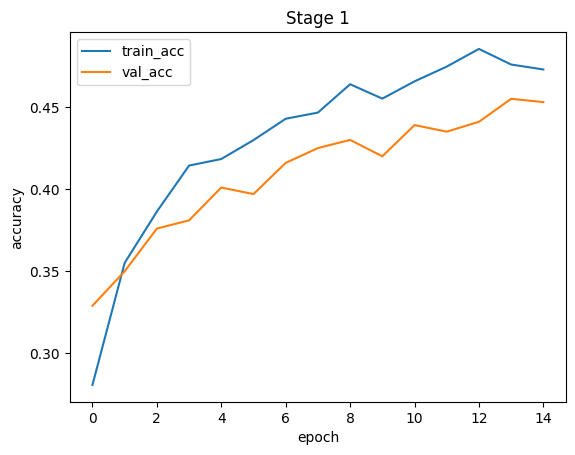

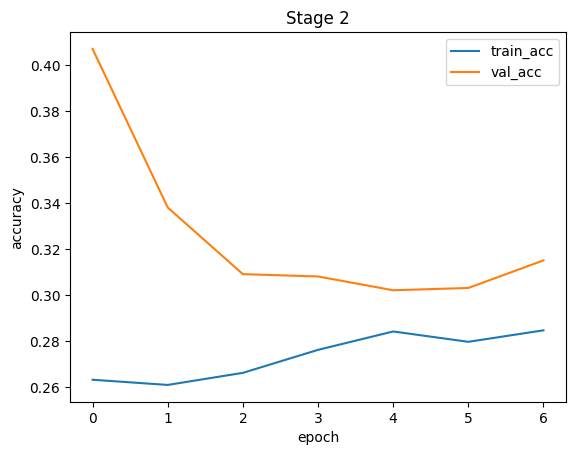

In [18]:
import matplotlib.pyplot as plt

def plot_hist(hist, title):
    plt.figure()
    plt.plot(hist.history["accuracy"], label="train_acc")
    plt.plot(hist.history["val_accuracy"], label="val_acc")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.show()

plot_hist(hist1, "Stage 1")
plot_hist(hist2, "Stage 2")


In [20]:
!pip install -q face-alignment torch torchvision


ERROR: Could not find a version that satisfies the requirement torchvision (from versions: none)
ERROR: No matching distribution found for torchvision


In [ ]:
import cv2, math, numpy as np
import face_alignment
import torch 

IMG_SIZE = 260
TOP_MARGIN = 0.35
BOTTOM_MARGIN = 0.60
SIDE_MARGIN = 0.28

device = "cuda" if torch.cuda.is_available() else "cpu"
fa = face_alignment.FaceAlignment(
    face_alignment.LandmarksType.TWO_D,
    device=device,
    flip_input=False
)

print("face-alignment device:", device)


c:\Users\Admin\miniconda3\envs\innovation_project\Lib\site-packages\face_alignment\api.py:130: UserWarning: Compiling face alignment model (one-time cost). Subsequent runs will be faster.
  warnings.warn(


In [29]:
import cv2, math, numpy as np
import face_alignment
import torch

IMG_SIZE = 260
TOP_MARGIN = 0.35
BOTTOM_MARGIN = 0.60
SIDE_MARGIN = 0.28

device = "cuda" if torch.cuda.is_available() else "cpu"
fa = face_alignment.FaceAlignment(
    face_alignment.LandmarksType.TWO_D,
    device=device,
    flip_input=False
)

print("face-alignment device:", device)

def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def rotate(img, angle, center):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    out = cv2.warpAffine(img, M, (w, h),
                         flags=cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_REPLICATE)
    return out, M

def apply(M, x, y):
    return (
        M[0,0]*x + M[0,1]*y + M[0,2],
        M[1,0]*x + M[1,1]*y + M[1,2]
    )

def crop_face(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    lms_list = fa.get_landmarks(img_rgb)
    if not lms_list:
        return None

    lms = lms_list[0]  # largest face
    h, w = img_bgr.shape[:2]

    # eye centers
    left_eye = lms[36:42].mean(axis=0)
    right_eye = lms[42:48].mean(axis=0)

    angle = math.degrees(math.atan2(
        right_eye[1] - left_eye[1],
        right_eye[0] - left_eye[0]
    ))

    rot, M = rotate(img_bgr, -angle, (w/2, h/2))
    rpts = np.array([apply(M, x, y) for x, y in lms])

    x1, y1 = rpts.min(axis=0)
    x2, y2 = rpts.max(axis=0)
    fw, fh = x2 - x1, y2 - y1
    if fw < 5 or fh < 5:
        return None

    nx1 = int(clamp(x1 - SIDE_MARGIN*fw, 0, w))
    nx2 = int(clamp(x2 + SIDE_MARGIN*fw, 0, w))
    ny1 = int(clamp(y1 - TOP_MARGIN*fh, 0, h))
    ny2 = int(clamp(y2 + BOTTOM_MARGIN*fh, 0, h))

    crop = rot[ny1:ny2, nx1:nx2]
    if crop.size == 0:
        return None

    crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
    return crop


Downloading: "https://www.adrianbulat.com/downloads/python-fan/s3fd-619a316812.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\s3fd-619a316812.pth


100%|██████████| 85.7M/85.7M [00:21<00:00, 4.15MB/s]
Downloading: "https://www.adrianbulat.com/downloads/python-fan/2DFAN4-11f355bf06.pth.tar" to C:\Users\Admin/.cache\torch\hub\checkpoints\2DFAN4-11f355bf06.pth.tar
100%|██████████| 91.2M/91.2M [00:19<00:00, 4.93MB/s]
c:\Users\Admin\miniconda3\envs\innovation_project\Lib\site-packages\face_alignment\api.py:130: UserWarning: Compiling face alignment model (one-time cost). Subsequent runs will be faster.
  warnings.warn(
torch.compile failed (RuntimeError: Compiler: cl is not found.

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you're reporting a bug to PyTorch). For even more developer context, set TORCH_LOGS="+dynamo"
), using eager mode


face-alignment device: cpu


In [22]:
import numpy as np
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/face_shape_b0_260_final.keras"
model = tf.keras.models.load_model(MODEL_PATH)

class_names = ["Heart", "Oblong", "Oval", "Round", "Square"]  # VERIFY order!

def predict_face_shape(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image not found")

    face = crop_face(img)
    if face is None:
        raise ValueError("No face detected")

    x = face.astype(np.float32) / 255.0
    x = np.expand_dims(x, axis=0)

    probs = model.predict(x, verbose=0)[0]
    order = probs.argsort()[::-1]
    top2 = [(class_names[i], float(probs[i])) for i in order[:2]]
    return top2, probs


In [ ]:
img_path = "/content/drive/MyDrive/dataset/testing_set/Heart/heart (101).jpg"
top2, probs = predict_face_shape(img_path)
print("Top-2 face shapes:", top2)


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3587334254.py, line 1)

In [28]:
import os
PROC_DIR = "C:\Users\Admin\OneDrive\Desktop\sem2\Innovation\archive_processed_224"
print("Real class folder order (sorted):")
print(sorted(os.listdir(f"{PROC_DIR}/training_set")))


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3166771168.py, line 2)

In [ ]:
for i, p in enumerate(probs):
    print(f"{class_names[i]:<8}: {p:.3f}")


Heart   : 0.203
Oblong  : 0.205
Oval    : 0.197
Round   : 0.200
Square  : 0.195


In [ ]:
import numpy as np
import cv2

# ✅ confirmed correct order from folders
class_names = ["Heart", "Oblong", "Oval", "Round", "Square"]

STYLE_LIBRARY = {
    "Round":  {"best":["High fade + textured top","Short quiff (controlled height)","Side part with volume"],
               "avoid":["Heavy straight fringe","Bowl / very rounded cuts"],
               "note":"Add height and angles to reduce roundness."},

    "Square": {"best":["Crew cut / Ivy League","Textured crop + mid fade","Side part taper"],
               "avoid":["Ultra boxy flat-top"],
               "note":"Strong jaw works best with texture and clean structure."},

    "Oblong": {"best":["Textured fringe (light)","Curtains / medium layered cut","Low taper + natural top"],
               "avoid":["High pompadour","Very tall top with high fade"],
               "note":"Reduce face length; avoid excess height."},

    "Heart":  {"best":["Side-swept fringe","Textured crop (medium height)","Low taper + layered top"],
               "avoid":["Tight sides with huge top volume"],
               "note":"Soften wide forehead; keep top balanced."},

    "Oval":   {"best":["Textured crop","Side part (moderate volume)","Curtains"],
               "avoid":["Extreme height styles"],
               "note":"Balanced face—most styles work, avoid extremes."},
}

def recommend_hairstyles(top2):
    (s1, p1), (s2, p2) = top2
    p_sum = (p1 + p2) if (p1 + p2) > 0 else 1.0
    w1, w2 = p1/p_sum, p2/p_sum

    scores = {}
    for style in STYLE_LIBRARY[s1]["best"]:
        scores[style] = scores.get(style, 0.0) + 1.0*w1
    for style in STYLE_LIBRARY[s2]["best"]:
        scores[style] = scores.get(style, 0.0) + 1.0*w2

    recs = [k for k,_ in sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]]
    avoid = list(dict.fromkeys(STYLE_LIBRARY[s1]["avoid"] + STYLE_LIBRARY[s2]["avoid"]))
    why = [f"{s1}: {STYLE_LIBRARY[s1]['note']}", f"{s2}: {STYLE_LIBRARY[s2]['note']}"]
    return recs, avoid, why

def predict_and_recommend(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image not found / unreadable")

    face = crop_face(img)   # face-alignment crop
    if face is None:
        raise ValueError("No face detected")

    # ✅ IMPORTANT: keep 0–255 range (NO /255)
    x = face.astype(np.float32)
    x = np.expand_dims(x, axis=0)

    probs = model.predict(x, verbose=0)[0]
    order = probs.argsort()[::-1]
    top2 = [(class_names[i], float(probs[i])) for i in order[:2]]

    recs, avoid, why = recommend_hairstyles(top2)

    return {
        "top2_shapes": top2,
        "all_probs": {class_names[i]: float(probs[i]) for i in range(len(class_names))},
        "recommended": recs,
        "avoid": avoid,
        "why": why
    }


In [ ]:
img_path = "/content/drive/MyDrive/face_shape_project/square (147).jpg"  # or any square image
result = predict_and_recommend(img_path)

print("Top-2:", result["top2_shapes"])
print("\nAll probs:")
for k,v in result["all_probs"].items():
    print(f"{k:<7}: {v:.3f}")


Top-2: [('Square', 0.4456366002559662), ('Oblong', 0.26488104462623596)]

All probs:
Heart  : 0.089
Oblong : 0.265
Oval   : 0.136
Round  : 0.064
Square : 0.446


In [ ]:
import os, random

FOLDER = "/content/drive/MyDrive/face_shape_project"
exts = (".jpg",".jpeg",".png",".webp")

imgs = [os.path.join(FOLDER,f) for f in os.listdir(FOLDER) if f.lower().endswith(exts)]
random.shuffle(imgs)

for p in imgs[:20]:
    try:
        r = predict_and_recommend(p)
        print("\n===", os.path.basename(p), "===")
        print("Top-2:", r["top2_shapes"])
        print("Recs:", r["recommended"])
    except Exception as e:
        print("\n===", os.path.basename(p), "===")
        print("FAILED:", str(e))



=== square (229).jpg ===
Top-2: [('Oblong', 0.28156137466430664), ('Square', 0.25222817063331604)]
Recs: ['Textured fringe (light)', 'Curtains / medium layered cut', 'Low taper + natural top']

=== square (148).jpg ===
Top-2: [('Oval', 0.2712935209274292), ('Oblong', 0.263310045003891)]
Recs: ['Textured crop', 'Side part (moderate volume)', 'Curtains']

=== square (150).jpg ===
Top-2: [('Square', 0.3863086402416229), ('Oblong', 0.30987614393234253)]
Recs: ['Crew cut / Ivy League', 'Textured crop + mid fade', 'Side part taper']

=== square (158).jpg ===
Top-2: [('Square', 0.2714976370334625), ('Oblong', 0.22284719347953796)]
Recs: ['Crew cut / Ivy League', 'Textured crop + mid fade', 'Side part taper']

=== square (1).jpg ===
Top-2: [('Round', 0.5339820981025696), ('Square', 0.1873866319656372)]
Recs: ['High fade + textured top', 'Short quiff (controlled height)', 'Side part with volume']

=== square (160).jpg ===
Top-2: [('Square', 0.277859628200531), ('Oblong', 0.26899459958076477)]


In [ ]:
import tensorflow as tf
import os

KERAS_PATH = "/content/drive/MyDrive/face_shape_b0_260_final.keras"
TFLITE_PATH = "/content/drive/MyDrive/face_shape_b0_260_final.tflite"

model = tf.keras.models.load_model(KERAS_PATH)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = []  # keep float32 for best accuracy
tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

print("✅ Saved TFLite:", TFLITE_PATH, "| size:", os.path.getsize(TFLITE_PATH)/1024/1024, "MB")


Saved artifact at '/tmp/tmpej2ido3_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 260, 260, 3), dtype=tf.float32, name='input_layer_7')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138989687784080: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138989687794064: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138989718231312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718232848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718233040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718237648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718235536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718230160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718235344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718231696: TensorSpec(shape=(), dtype=tf.resource, name=Non